# Enterprise Data Architecture & Reconciliation

## The Scenario
You are a Senior Data Analyst at a massive FinTech company. The Data Engineering team is on vacation, and the CFO needs the Q1-Q4 Financial Audit Dashboard by Friday.

You have been given access to three separate, messy systems:
1. **The HR Database (`enterprise_database.db`):** A SQL database containing user accounts. *Warning: It contains historical logs, meaning users appear multiple times. You only want their most recent status.*
2. **The Server Logs (`server_logs.txt`):** 100,000 raw text logs. The transaction data is trapped inside strings.
3. **The Finance Server (`daily_exchange_rates.csv`):** A list of daily EUR to USD exchange rates. *Warning: The financial market is closed on weekends, so weekend dates have missing exchange rates.*

## Your Mission
You must architect a Python pipeline to extract, clean, merge, and visualize this data.

**Requirements for Passing:**
1. **Advanced SQL:** Extract only "Active" users from the database using the most recent `updated_at` timestamp.
2. **String Manipulation (Regex):** Extract the Date, User ID, Product ID, and Euro Value from the raw text logs. Filter out rows labeled "ERROR".
3. **Temporal Joins:** Join the transactions to the exchange rate table based on the exact day. You must forward-fill the weekend exchange rates so transactions don't drop out.
4. **Efficiency:** Your code must run on all 100,000 rows in under 2 minutes. No `for` loops allowed in Pandas.
5. **Dashboard:** Build visualizations showing Total USD Revenue by Month and Top 5 Most Valuable Customers.

In [1]:
# ===================================================================
# PHASE 1: SQL EXTRACTION
# ===================================================================
import sqlite3
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to 'enterprise_database.db'
conn = sqlite3.connect("enterprise_database_.db")
# 2. Write a SQL query (using Window Functions or Subqueries) to get the most
#    recent status for each user.
# 3. Only keep users whose latest status is 'Active'.
query = """
SELECT *
FROM (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY user_id
               ORDER BY updated_at DESC
           ) AS rn
    FROM users
) latest_users
WHERE rn = 1
  AND status = 'Active';
"""
# 4. Load the result into a Pandas DataFrame called 'df_active_users'.
df_active_users = pd.read_sql(query, conn)
df_active_users.head()

# [WRITE YOUR SQL AND PYTHON CODE HERE]

,user_id,name,status,updated_at,rn
0,U-00001,User_U-00001,Active,2023-01-28 14:00:00,1
1,U-00003,User_U-00003,Active,2023-01-22 14:00:00,1
2,U-00005,User_U-00005,Active,2023-01-17 14:00:00,1
3,U-00006,User_U-00006,Active,2023-01-05 14:00:00,1
4,U-00007,User_U-00007,Active,2023-01-27 14:00:00,1


In [14]:
# ===================================================================
# PHASE 2: REGEX & UNSTRUCTURED DATA WRANGLING
# ===================================================================

# 1. Load 'server_logs.txt' into a DataFrame.
logs = pd.read_csv("server_logs.txt", header=None, names=["Raw_Log"])

# 2. Drop any rows where the log contains the word "ERROR".
logs = logs[~logs["Raw_Log"].str.contains("ERROR", na=False)].copy()

# 3. Use Pandas string methods (.str.extract()) or Python Regex to pull the
#    Date, User ID, Product ID, and Euro Value out of the raw text string.
pattern = r"\[(.*?)\].*?u\":\"(.*?)\".*?item_code\":\"(.*?)\".*?eur_val\":([\d.]+)"

extracted_data = logs["Raw_Log"].str.extract(pattern)

extracted_data.columns = ["Date", "User_ID", "Product_ID", "Euro_Value"]

# 4. Save this cleaned data to a new DataFrame called 'extracted_data'.
extracted_data["Date"] = pd.to_datetime(extracted_data["Date"])
extracted_data["Euro_Value"] = extracted_data["Euro_Value"].astype(float)
extracted_data.head()

# Remove rows where extraction failed
extracted_data = extracted_data.dropna()

# Reset index
extracted_data = extracted_data.reset_index(drop=True)

# Check the cleaned data
extracted_data.head()

,Date,User_ID,Product_ID,Euro_Value
0,2023-03-15,U-19484,PRD-874,3404.44
1,2023-05-09,U-18932,PRD-905,3406.21
2,2023-10-21,U-15882,PRD-284,164.08
3,2023-01-10,U-22781,PRD-665,26.80
4,2023-05-23,U-13348,PRD-589,4964.77


In [20]:
# ===================================================================
# PHASE 3: FINANCIAL RECONCILIATION & MERGING
# ===================================================================

# 1. Load 'daily_exchange_rates.csv' into a DataFrame.
exchange_rates = pd.read_csv("daily_exchange_rates.csv")

exchange_rates.head()

# 2. Handle the missing weekend data using a method like .fillna(method='ffill')
#    so Friday's rate rolls over to Saturday and Sunday.
exchange_rates["EUR_to_USD"] = exchange_rates["EUR_to_USD"].ffill()

exchange_rates.head()

# 3. Merge your cleaned logs with the exchange rates by Date.
extracted_data["Date"] = pd.to_datetime(extracted_data["Date"])
exchange_rates["Date"] = pd.to_datetime(exchange_rates["Date"])
df_merged = pd.merge(
    extracted_data,
    exchange_rates,
    on="Date",
    how="left"
)
df_merged.head()
# 4. Merge that result with your active SQL users by User ID.
df_merged.columns
df_active_users.columns
df_final = pd.merge(
    df_merged,
    df_active_users,
    left_on="User_ID",
    right_on="user_id",
    how="inner"
)

df_final.head()




# 5. Calculate a new column called 'USD_Revenue' (Euro Value * Exchange Rate).
df_final["USD_Revenue"] = df_final["Euro_Value"] * df_final["EUR_to_USD"]

df_final.head()
# 6. Save the final merged table as 'df_final'.
df_final.to_csv("df_final.csv", index=False)
df_final.head()
df_final.shape
df_final.to_excel("df_final.xlsx", index=False)
# [WRITE YOUR MERGING AND MATH CODE HERE]

In [21]:
# ===================================================================
# PHASE 4: AGGREGATION & VISUALIZATION (CFO DASHBOARD)
# ===================================================================


In [24]:
# 1. Group the data in 'df_final' to calculate Total USD Revenue by Month.
df_final["Month"] = df_final["Date"].dt.to_period("M").astype(str)

monthly_revenue = (
    df_final.groupby("Month")["USD_Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,Month,USD_Revenue
0,2023-01,1.284176e+07
1,2023-02,1.143613e+07
2,2023-03,1.234893e+07
3,2023-04,1.201538e+07
4,2023-05,1.233364e+07
5,2023-06,1.208436e+07
6,2023-07,1.244416e+07
7,2023-08,1.281273e+07
8,2023-09,1.222895e+07
9,2023-10,1.250133e+07


In [25]:
# 2. Group the data to find the Top 5 Most Valuable Customers by Total USD spent.
top_customers = (
    df_final.groupby("name")["USD_Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

top_customers

,name,USD_Revenue
0,User_U-06582,40050.988262
1,User_U-23313,39555.806629
2,User_U-03805,39529.945085
3,User_U-20018,38649.965242
4,User_U-06489,38629.142146


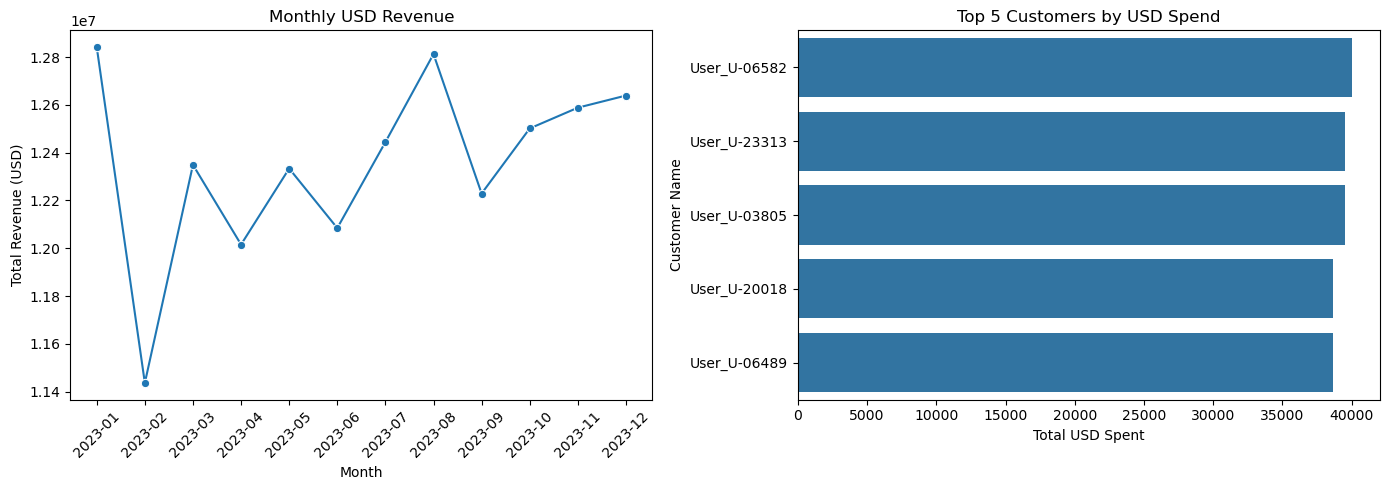

In [19]:
# 3. Use Matplotlib or Seaborn to generate two charts side-by-side:
#    - Chart 1: A Line Chart or Bar Chart showing Revenue by Month.
#    - Chart 2: A Bar Chart showing the Top 5 Customers.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,5))

# Chart 1: Revenue by Month
plt.subplot(1,2,1)

sns.lineplot(
    data=monthly_revenue,
    x="Month",
    y="USD_Revenue",
    marker="o"
)

plt.title("Monthly USD Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=45)

# Chart 2: Top 5 Customers
plt.subplot(1,2,2)

sns.barplot(
    data=top_customers,
    x="USD_Revenue",
    y="name"
)

plt.title("Top 5 Customers by USD Spend")
plt.xlabel("Total USD Spent")
plt.ylabel("Customer Name")


plt.tight_layout()
plt.show()

In [26]:
#PHASE 5 Export dataset for Power BI
df_final.to_csv('power_bi_ready_dataset.csv', index=False)

In [13]:
df_final.head(5)

,Date,User_ID,Product_ID,Euro_Value,EUR_to_USD,user_id,name,status,updated_at,rn,USD_Revenue,Month
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,U-19484,User_U-19484,Active,2023-01-11 14:00:00,1,4011.220772,2023-03
1,2023-10-21,U-15882,PRD-284,164.08,1.075350,U-15882,User_U-15882,Active,2023-01-16 14:00:00,1,176.443420,2023-10
2,2023-01-10,U-22781,PRD-665,26.80,1.127128,U-22781,User_U-22781,Active,2023-01-07 14:00:00,1,30.207030,2023-01
3,2023-10-20,U-22062,PRD-363,48.63,1.075350,U-22062,User_U-22062,Active,2023-01-05 14:00:00,1,52.294268,2023-10
4,2023-12-02,U-22146,PRD-223,960.60,1.066142,U-22146,User_U-22146,Active,2023-01-18 14:00:00,1,1024.135923,2023-12
